In [38]:
import pandas as pd
import numpy as np
import re

sales = pd.read_csv("sales_transactions.csv")
stores = pd.read_csv("store_info.csv")

In [39]:
print(sales.shape)
print(stores.shape)
sales.head()

(3085, 12)
(30, 6)


,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,Sports,2,activepro,East,59.53,121.7,31,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,Beauty,2,Glow Works,West,17.62,40.84,10,NaN,119.32
2,T000623,S03,NaN,Electronics,1,NORTHSTAR,North,235.26,308.8,145,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,Grocery,2,FreshFarm,West,6.41,10.74,14,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,Electronics,8,NorthStar,East,231.33,289.13,48,5.34,113.35


In [40]:
# Duplicate transactions
duplicate_count = int(sales.duplicated().sum())
sales = sales.drop_duplicates().copy()
print("Duplicates removed:", duplicate_count)

Duplicates removed: 85


In [5]:
# Checking ID consistency
print(sales["transaction_id"].unique()[:20])
print(sales["transaction_id"].duplicated().sum())

['T000571' 'T000763' 'T000623' 'T000827' 'T000175' 'T000865' 'T001088'
 'T001320' 'T002753' 'T002610' 'T001297' 'T002840' 'T002834' 'T001688'
 'T001074' 'T002179' 'T002172' 'T002437' 'T001923' 'T000431']
0


In [7]:
# Standardize store_id and region in store_info
def normalize_store_id(x):
    if pd.isna(x):
        return pd.NA
    digits = "".join(re.findall(r"\d+", str(x)))
    if digits == "":
        return pd.NA
    return "S" + digits.zfill(2)

def clean_region(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    region_map = {
        "e": "East", "east": "East",
        "w": "West", "west": "West",
        "n": "North", "north": "North",
        "s": "South", "south": "South",
    }
    return region_map.get(s, pd.NA)

stores["store_id_clean"] = stores["store_id"].apply(normalize_store_id)
stores["region_clean"] = stores["region"].apply(clean_region)

print("store_id missing after cleaning:", stores["store_id_clean"].isna().sum())
print("region missing after cleaning:", stores["region_clean"].isna().sum())

store_id missing after cleaning: 0
region missing after cleaning: 0


In [10]:
# Standardize supplier
def clean_supplier(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    supplier_map = {
        "northstar": "NorthStar", "north star": "NorthStar", "north-star": "NorthStar",
        "glowworks": "GlowWorks", "glow works": "GlowWorks",
        "freshfarm": "FreshFarm", "fresh farm": "FreshFarm",
        "budgetsource": "BudgetSource", "budget source": "BudgetSource",
        "activepro": "ActivePro", "active pro": "ActivePro",
        "stylehub": "StyleHub", "style hub": "StyleHub",
    }
    return supplier_map.get(s, pd.NA)

sales["supplier_clean"] = sales["supplier"].apply(clean_supplier)
print("supplier missing after cleaning:", sales["supplier_clean"].isna().sum())
print(sales["supplier_clean"].unique())

supplier missing after cleaning: 0
['ActivePro' 'GlowWorks' 'NorthStar' 'FreshFarm' 'BudgetSource' 'StyleHub']


In [37]:
# Standardize product categories
def clean_category(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    category_map = {
        "electronics": "Electronics", "electronic": "Electronics",
        "apparel": "Apparel", "clothing": "Apparel",
        "grocery": "Grocery", "groceries": "Grocery", "food": "Grocery",
        "home": "Home", "home goods": "Home",
        "sports": "Sports", "sporting goods": "Sports",
        "beauty": "Beauty", "cosmetics": "Beauty",
    }
    return category_map.get(s, pd.NA)

sales["category_clean"] = sales["product_category"].apply(clean_category)
print("category missing after cleaning:", sales["category_clean"].isna().sum())
print(sales["category_clean"].unique())

category missing after cleaning: 0
['Sports' 'Beauty' 'Electronics' 'Grocery' 'Home' 'Apparel']


In [12]:
# Quantity validation
sales["quantity_clean"] = pd.to_numeric(sales["quantity"], errors="coerce")
invalid_quantity_mask = sales["quantity_clean"].isna() | (sales["quantity_clean"] <= 0)
invalid_quantity_count = int(invalid_quantity_mask.sum())
print("Invalid quantity records:", invalid_quantity_count)

Invalid quantity records: 120


In [13]:
# Sales date
sales["sale_date_clean"] = pd.to_datetime(sales["sale_date"], errors="coerce", format="mixed")
invalid_date_count = int(sales["sale_date_clean"].isna().sum())
print("Invalid sale_date records:", invalid_date_count)

Invalid sale_date records: 60


In [14]:
# Currency cleaning
def clean_currency(series):
    s = series.astype("string").str.replace("$", "", regex=False)
    s = s.str.replace("CAD", "", regex=False)
    s = s.str.strip()
    return pd.to_numeric(s, errors="coerce")

sales["unit_cost_clean"] = clean_currency(sales["unit_cost"])
sales["unit_price_clean"] = clean_currency(sales["unit_price"])
sales["labour_cost_clean"] = clean_currency(sales["labour_cost"])

print("unit_cost missing:", sales["unit_cost_clean"].isna().sum())
print("unit_price missing:", sales["unit_price_clean"].isna().sum())
print("labour_cost missing:", sales["labour_cost_clean"].isna().sum())

unit_cost missing: 75
unit_price missing: 0
labour_cost missing: 0


In [15]:
# Cleaning inventory levels and labour hours
sales["inventory_level_clean"] = pd.to_numeric(sales["inventory_level"], errors="coerce")

sales["labour_hours_clean"] = pd.to_numeric(sales["labour_hours"], errors="coerce")
sales.loc[sales["labour_hours_clean"] < 0, "labour_hours_clean"] = np.nan

print("inventory_level missing after cleaning:", sales["inventory_level_clean"].isna().sum())
print("labour_hours missing/invalid after cleaning:", sales["labour_hours_clean"].isna().sum())

inventory_level missing after cleaning: 60
labour_hours missing/invalid after cleaning: 85


In [16]:
print("labour_hours missing:", sales["labour_hours"].isna().sum())

labour_hours missing: 32


In [28]:
# Standardize store_id in sales, then merge with store_info
sales["store_id_clean"] = sales["store_id"].apply(normalize_store_id)

sales_merged = sales.merge(
    stores[["store_id_clean", "region_clean", "manager", "store_size", "store_type", "opening_year"]],
    on="store_id_clean",
    how="left"
)
print(sales_merged.shape)
print("unmatched stores:", sales_merged["region_clean"].isna().sum())

(3000, 27)
unmatched stores: 0


In [26]:
# Final row filtering
final_sales = sales_merged[
    (sales_merged["quantity_clean"].notna()) & (sales_merged["quantity_clean"] > 0)
    & sales_merged["sale_date_clean"].notna()
    & sales_merged["unit_cost_clean"].notna()
    & sales_merged["unit_price_clean"].notna()
    & sales_merged["supplier_clean"].notna()
    & sales_merged["category_clean"].notna()
    & sales_merged["region_clean"].notna()
].copy()

print("Final row count:", len(final_sales))

Final row count: 2750


In [31]:
# Calculate revenue and profit
final_sales["revenue"] = final_sales["quantity_clean"] * final_sales["unit_price_clean"]
final_sales["gross_profit"] = (final_sales["unit_price_clean"] - final_sales["unit_cost_clean"]) * final_sales["quantity_clean"]

total_revenue = round(final_sales["revenue"].sum(), 2)
total_gross_profit = round(final_sales["gross_profit"].sum(), 2)

print("Total revenue:", total_revenue)
print("Total gross profit:", total_gross_profit)

Total revenue: 901301.12
Total gross profit: 302876.91


In [20]:
import matplotlib.pyplot as plt

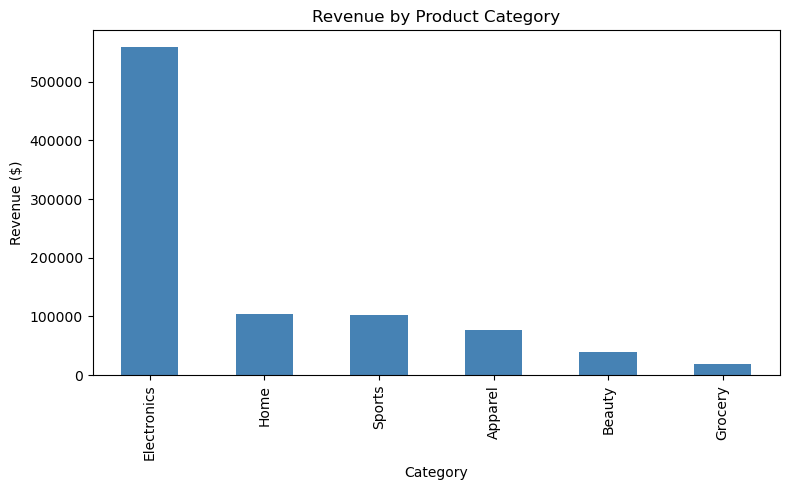

In [21]:
# Revenue by product category
category_revenue = final_sales.groupby("category_clean")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind="bar", color="steelblue")
plt.title("Revenue by Product Category")
plt.ylabel("Revenue ($)")
plt.xlabel("Category")
plt.tight_layout()
plt.show()

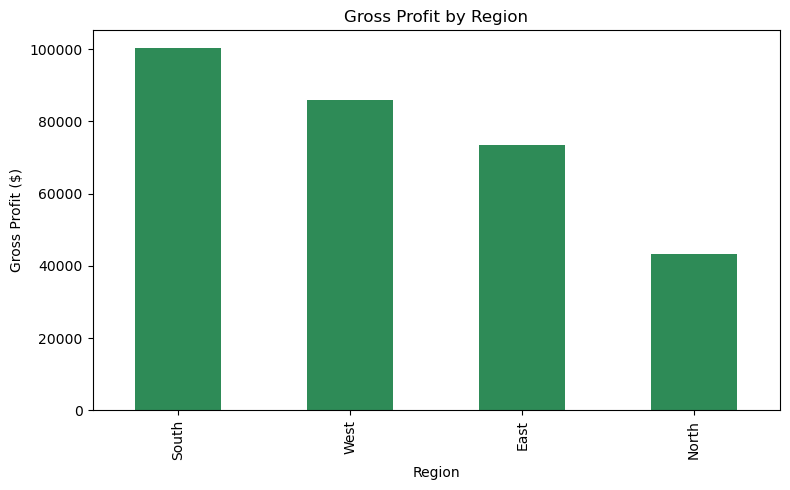

In [22]:
# Gross profit by region
region_profit = final_sales.groupby("region_clean")["gross_profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_profit.plot(kind="bar", color="seagreen")
plt.title("Gross Profit by Region")
plt.ylabel("Gross Profit ($)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

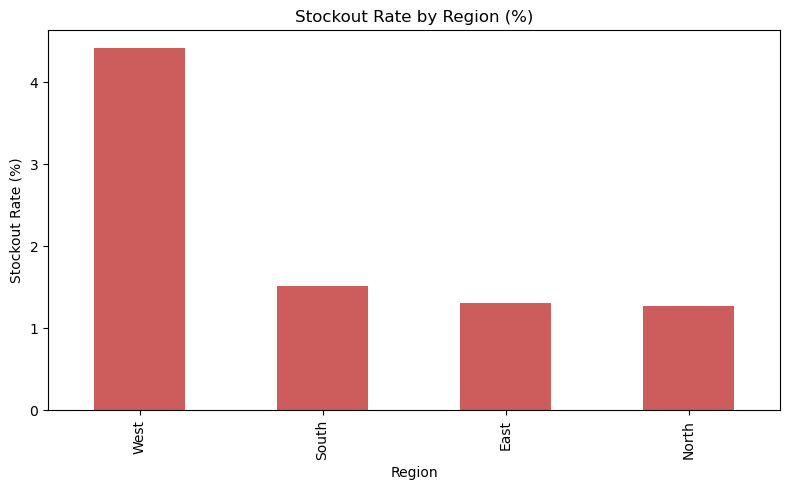

In [23]:
# Stockout rate by region
final_sales["stockout"] = (final_sales["inventory_level_clean"] <= 0).astype("Int64")
stockout_rate = final_sales.groupby("region_clean")["stockout"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,5))
stockout_rate.plot(kind="bar", color="indianred")
plt.title("Stockout Rate by Region (%)")
plt.ylabel("Stockout Rate (%)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

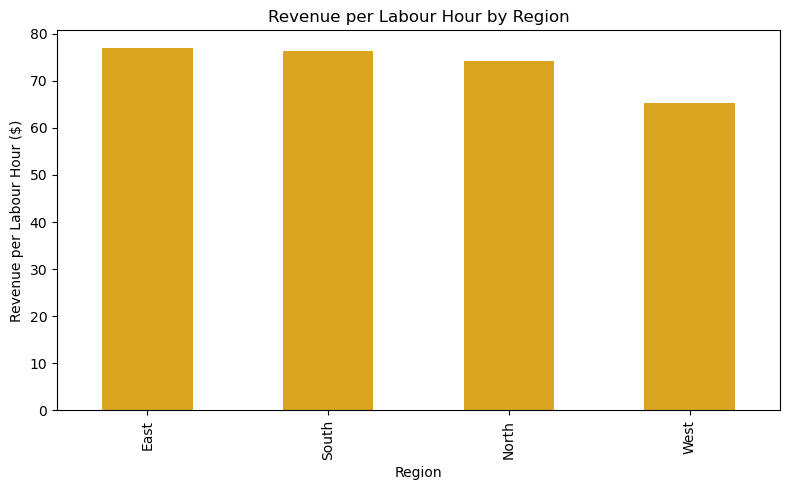

In [24]:
# Revenue per labour hour by region
labour_valid = final_sales[final_sales["labour_hours_clean"].notna()]
labour_eff = labour_valid.groupby("region_clean").apply(
    lambda d: d["revenue"].sum() / d["labour_hours_clean"].sum()
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
labour_eff.plot(kind="bar", color="goldenrod")
plt.title("Revenue per Labour Hour by Region")
plt.ylabel("Revenue per Labour Hour ($)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

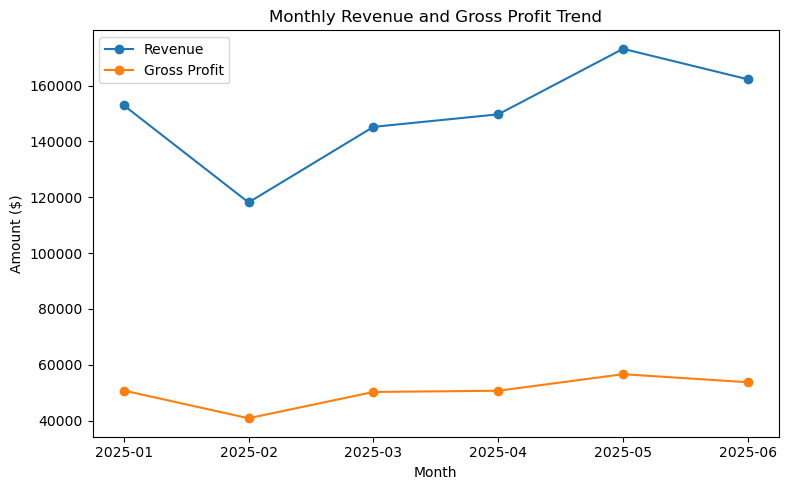

In [36]:
# Revenue and profit trend over time
final_sales["sale_month"] = final_sales["sale_date_clean"].dt.to_period("M")
monthly_trend = final_sales.groupby("sale_month")[["revenue", "gross_profit"]].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_trend.index.astype(str), monthly_trend["revenue"], marker="o", label="Revenue")
plt.plot(monthly_trend.index.astype(str), monthly_trend["gross_profit"], marker="o", label="Gross Profit")
plt.title("Monthly Revenue and Gross Profit Trend")
plt.ylabel("Amount ($)")
plt.xlabel("Month")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
final_sales.to_csv("clean_sales_analysis.csv", index=False)